# GaP core workflow: coarse grid to center LGR

This notebook is a pure GaP demonstration. It starts from an existing coarse simulator grid, defines a minimal synthetic well geometry, builds a center local grid refinement (LGR), writes a GRDECL, and compares coarse vs refined permeability slices.

In [14]:
from pathlib import Path
import tempfile

import matplotlib.pyplot as plt
import pandas as pd

from src.WellClass.libs.grid_utils import LGRBuilder

## Scope

This notebook isolates GaP grid generation mechanics:

1. read coarse grid (`GridCoarse` through `LGRBuilder`),
2. provide geometric intervals (`annulus`, `holes`, `casings`, `barriers`) as dataframes,
3. run LGR generation and property assignment,
4. visualize mesh properties before and after refinement.

No WellClass parsing or schema conversion is used here.

## Input to LGR flow

```mermaid
flowchart LR
    A[Input case path\nEGRID + INIT] --> B[LGRBuilder]
    C[Annulus dataframe\nthickness + depth intervals] --> B
    D[Holes dataframe\ndiameters + depths + oh_perm] --> B
    E[Casings dataframe\ngeometry + TOC/BOC + cb_perm] --> B
    F[Barrier dataframe\nintervals + barrier_perm] --> B

    B --> G[GridCoarse load\nNX NY NZ DX DY DZ + properties]
    G --> H[LGRGridInfo\nmin cell + XY pattern + Z layering]
    H --> I[GridRefine mesh\nupscale coarse properties]
    I --> J[Material assignment\nopenhole casing cement barrier]
    J --> K[PERMX/PERMY/PERMZ updates]
    K --> L[build_grdecl output\nCARFIN/LGR deck]
    I --> M[QC plots\ncoarse vs new_way vs ali_way]
```


In [15]:
root = Path.cwd()
if not (root / 'test_data').exists():
    root = root.parent

case = root / 'test_data/examples/wildcat/model/TEMP-0'
ali_way = False

# Minimal synthetic geometry inputs consumed by GaP.
annulus_df = pd.DataFrame([
    {'top_msl': 0.0, 'bottom_msl': 5200.0, 'thick_m': 0.08},
])

holes_df = pd.DataFrame([
    {'top_msl': 0.0, 'bottom_msl': 4300.0, 'diameter_m': 0.31115, 'oh_perm': 10000.0},
    {'top_msl': 4300.0, 'bottom_msl': 5200.0, 'diameter_m': 0.21600, 'oh_perm': 10000.0},
])

casings_df = pd.DataFrame([
    {'top_msl': 0.0, 'bottom_msl': 4200.0, 'toc_msl': 900.0, 'boc_msl': 4200.0, 'diameter_m': 0.17780, 'cb_perm': 0.05},
])

barrier_regions_df = pd.DataFrame([
    {'barrier_name': 'synthetic_barrier', 'top_msl': 4700.0, 'bottom_msl': 4900.0, 'diameter_m': 0.21600, 'barrier_perm': 0.01},
])

print({'case': str(case), 'ali_way': ali_way})

{'case': '/workspaces/SCREEN/test_data/examples/wildcat/model/TEMP-0', 'ali_way': False}


## Build LGR outputs for both refinement modes

In [16]:
builders = {}

for mode in (False, True):
    label = 'new_way' if not mode else 'ali_way'
    builder = LGRBuilder(str(case), annulus_df.copy(), holes_df.copy(), mode)
    with tempfile.TemporaryDirectory() as output_dir:
        gap_casing = builder.build_grdecl(
            output_dir,
            f'GAP_NOTEBOOK2_LGR_{label.upper()}',
            holes_df.copy(),
            casings_df.copy(),
            barrier_regions_df.copy(),
        )
        output_file = Path(output_dir) / f'GAP_NOTEBOOK2_LGR_{label.upper()}.grdecl'
        print({
            'mode': label,
            'output': str(output_file),
            'exists': output_file.exists(),
            'gap_casing_rows': len(gap_casing),
        })
    builders[label] = builder

for label, builder in builders.items():
    print({
        'mode': label,
        'coarse_dim': (builder.grid_coarse.NX, builder.grid_coarse.NY, builder.grid_coarse.NZ),
        'refined_dim': (builder.grid_refine.nx, builder.grid_refine.ny, builder.grid_refine.nz),
        'min_cell_m': builder.lgr_info.min_grd_size,
    })

Coarse grid dimension: nx=20, ny=20, nz=60
Minimimum grid size is 8.00 cm
LGR dimension: nx=10, ny=10, nz=150
...Prints isolating OVB from reservoir keywords in GAP_NOTEBOOK2_LGR_NEW_WAY.grdecl file
...Prints CARFIN Keywords in GAP_NOTEBOOK2_LGR_NEW_WAY.grdecl file
...Prints isolating OVB from reservoir in the LGR in GAP_NOTEBOOK2_LGR_NEW_WAY.grdecl file
...reopenID = 7.00 ...
Output LGR CARFIN to:  /tmp/tmppih28sqh/GAP_NOTEBOOK2_LGR_NEW_WAY.grdecl
{'mode': 'new_way', 'output': '/tmp/tmppih28sqh/GAP_NOTEBOOK2_LGR_NEW_WAY.grdecl', 'exists': True, 'gap_casing_rows': 1}
Coarse grid dimension: nx=20, ny=20, nz=60
Minimimum grid size is 8.00 cm
LGR dimension: nx=16, ny=16, nz=150
...Prints isolating OVB from reservoir keywords in GAP_NOTEBOOK2_LGR_ALI_WAY.grdecl file
...Prints CARFIN Keywords in GAP_NOTEBOOK2_LGR_ALI_WAY.grdecl file
...Prints isolating OVB from reservoir in the LGR in GAP_NOTEBOOK2_LGR_ALI_WAY.grdecl file
...reopenID = 7.00 ...
Output LGR CARFIN to:  /tmp/tmp138gyoa7/GAP_NO

In [17]:
for label, builder in builders.items():
    mesh = builder.grid_refine.mesh_df
    assert mesh['PERMX'].notna().all()
    assert (mesh['PERMX'] >= 0).all()
print('GaP LGR build checks passed for new_way and ali_way')

GaP LGR build checks passed for new_way and ali_way


## Numeric comparison of lateral refinement patterns

In [18]:
for label, builder in builders.items():
    lgr_x = builder.lgr_info.LGR_sizes_x
    left_half = lgr_x[: len(lgr_x) // 2]
    min_dx = min(lgr_x)
    max_dx = max(lgr_x)
    print({
        'mode': label,
        'nx': len(lgr_x),
        'min_dx_m': round(min_dx, 5),
        'max_dx_m': round(max_dx, 5),
        'grading_ratio_max_over_min': round(max_dx / min_dx, 3),
        'left_outer_3_dx_m': [round(value, 5) for value in left_half[:3]],
        'left_inner_3_dx_m': [round(value, 5) for value in left_half[-3:]],
    })

{'mode': 'new_way', 'nx': 10, 'min_dx_m': np.float64(0.08), 'max_dx_m': np.float64(90.64177), 'grading_ratio_max_over_min': np.float64(1133.022), 'left_outer_3_dx_m': [np.float64(90.64177), np.float64(8.41668), np.float64(0.78154)], 'left_inner_3_dx_m': [np.float64(0.78154), np.float64(0.08), np.float64(0.08)]}
{'mode': 'ali_way', 'nx': 16, 'min_dx_m': 0.05, 'max_dx_m': np.float32(94.25), 'grading_ratio_max_over_min': np.float32(1885.0), 'left_outer_3_dx_m': [np.float32(94.25), 5.0, 0.5], 'left_inner_3_dx_m': [0.05, 0.05, 0.05]}


## Visual quality control: coarse vs new way vs Ali way

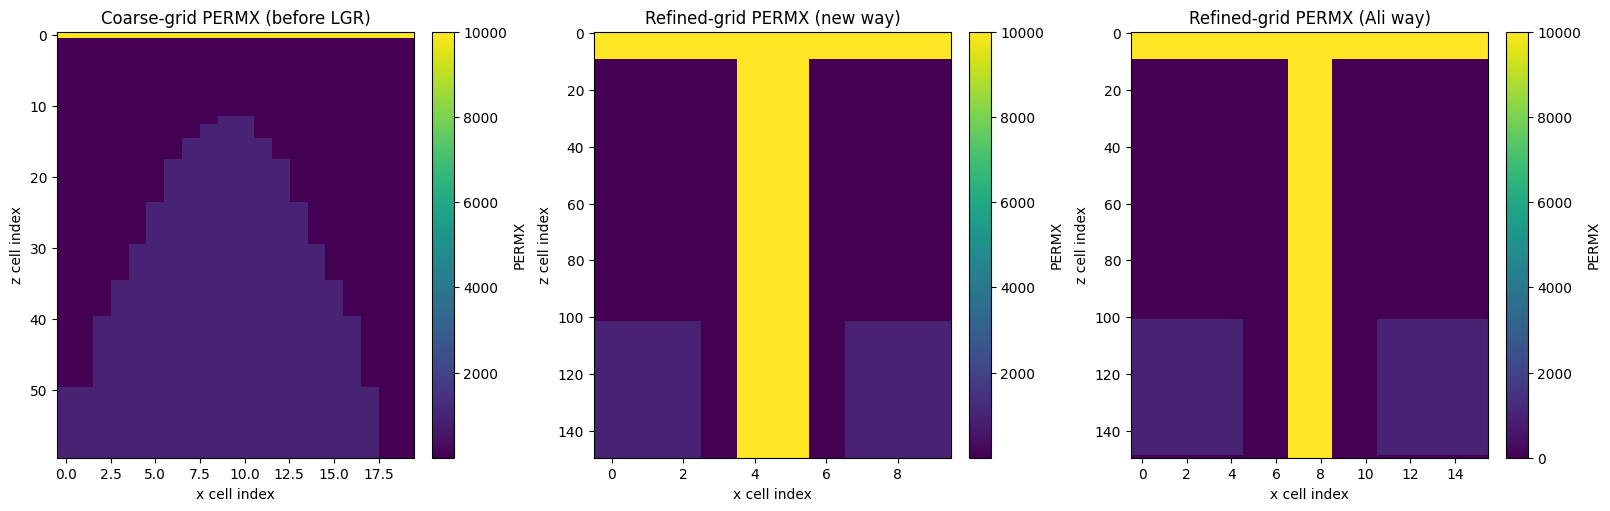

In [19]:
coarse_permx = builders['new_way'].grid_coarse.extract_xz_slice('PERMX')
new_way_permx = builders['new_way'].grid_refine.extract_xz_slice('PERMX')
ali_way_permx = builders['ali_way'].grid_refine.extract_xz_slice('PERMX')

fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)

coarse_img = axes[0].imshow(coarse_permx, aspect='auto', origin='upper', interpolation='nearest', resample=False)
axes[0].set_title('Coarse-grid PERMX (before LGR)')
axes[0].set_xlabel('x cell index')
axes[0].set_ylabel('z cell index')
fig.colorbar(coarse_img, ax=axes[0], label='PERMX')

new_img = axes[1].imshow(new_way_permx, aspect='auto', origin='upper', interpolation='nearest', resample=False)
axes[1].set_title('Refined-grid PERMX (new way)')
axes[1].set_xlabel('x cell index')
axes[1].set_ylabel('z cell index')
fig.colorbar(new_img, ax=axes[1], label='PERMX')

ali_img = axes[2].imshow(ali_way_permx, aspect='auto', origin='upper', interpolation='nearest', resample=False)
axes[2].set_title('Refined-grid PERMX (Ali way)')
axes[2].set_xlabel('x cell index')
axes[2].set_ylabel('z cell index')
fig.colorbar(ali_img, ax=axes[2], label='PERMX')

plt.show()